# Classification of Astronomical Events using CNNs (I)
```Authors: Paul Alvarez updated: 20260727```

This study implements and evaluates various computer vision models to classify astronomical events from the Zwicky Transient Facility (ZTF) survey. The main objective is to perform real-bogus classification using 63×63 pixel triplet images (science, reference, and difference) and analyze its performance in a reduced sample size. Additionally, it extends to multiclass classification (transient, periodic, stochastic) and includes transfer learning experiments using MobileNetV2 and Braai.


This first notebook covers the construction of the dataset: Collection and download of stamps via the ALeRCE/ZTF API, alongside normalization, handling of corrupted or missing data, and binary labeling.

## Table of contents:
* [Required libraries](#Required-libraries)
* [Introduction](#Introduction)
* [Dataset construction](#Dataset)
* [Download stamps](#initial-naive-approach)
* [Cleaning and Normalization](#cleaning-and-normalization)
* [References](#References)

## Required libraries

In [19]:
from alerce.core import Alerce
from astropy.io import fits
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from functions import download_stamp, visual_fits, clean_labels, normalize_img, build_Xy
from astropy.io.fits.verify import VerifyWarning

import warnings
import json
import os
import time
import sqlalchemy as sa
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.simplefilter('ignore', category=VerifyWarning)

## Introduction

Astronomy is currently booming in the era of Big Data. Surveys like the Zwicky Transient Facility (ZFT) utilize the Samuel Oschin Telescope at Palomar Observatory to detect transient phenomena in the night sky (such as supernovae, asteroids, AGN). The volume of generated data is inhumanly analyzable; manual inspection and classification of each observation is beyond our capacity. In recent years, with the emergence of models and brokers like Braai, Deep-Hits, and ALeRCE, convolutional neural networks (CNNs) have become essential tools and a rapidly growing area of exploration at the intersection of artificial intelligence and astronomy.

To process these observational data, the CNN receives astronomical astronomical "stamps". These consist of a triplet of images: recent observation image (Science), a historical baseline image of the same region (Reference), and the Difference image, which is obtained by subtracting the Reference image from Science. For instance, if a new point source appears in Science that was absent in Reference, it will stand out in the Difference image. The neural network uses this change in the image's distribution to determine whether a transient event is present.

Alert brokers such as ALeRCE are employing various pipelines, combining autoated algorithms with expert visual inspection to construct their final classification, however, they rely on large-scale datasets for training. Consequently, this project addresses the challenge of evaluating CNN performance in a data-limited regime. The primary objective is to demonstrate that effective, viable classifier can be built using a small dataset (~5000 stamps), while exploring the impact of techniques such as data augmentation or transfer learning.

## Dataset construction

We connect to the ALeRCE API, from there we can extract information on astronomical events to build the database.

In [13]:
# Connect to the ALeRCE API according to their instructions
client = Alerce()

url = "https://raw.githubusercontent.com/alercebroker/usecases/master/alercereaduser_v4.json"
params = requests.get(url).json()['params']

engine = sa.create_engine(f"postgresql+psycopg2://{params['user']}:{params['password']}@{params['host']}/{params['dbname']}")
engine.begin()

We generated a series of queries to construct the master dataset. First, we queried for confirmed real transient events and bogus detections (noise). Importantly, each query was constructed to ensure internal class balance, mitigating potential issues associated with class imbalance, such as majority class bias.

In [18]:
# API queries to obtain data
query = """
(
    SELECT DISTINCT ON (oid) oid, class_name
    FROM probability
    WHERE classifier_name = 'stamp_classifier'
      AND probability >= 0.76
      AND class_name = 'SN'
    LIMIT 1250
)
UNION ALL
(
    SELECT DISTINCT ON (oid) oid, class_name
    FROM probability
    WHERE classifier_name = 'stamp_classifier'
      AND probability >= 0.90
      AND class_name = 'VS'
    LIMIT 1250
);
"""

df_real = pd.read_sql_query(query, engine)

In [16]:
# API queries to obtain data
query = """
SELECT DISTINCT ON (o.oid)
       o.oid,
       p.class_name
FROM object o
JOIN probability p
ON o.oid = p.oid
WHERE p.classifier_name = 'stamp_classifier'
  AND p.class_name = 'bogus'
ORDER BY o.oid, p.probability DESC
LIMIT 2500;  
"""

df_bogus = pd.read_sql_query(query, engine)

With both queries, real events (CV and SN) and bogus, we will build our dataset, where each valid observation will be assigned class 1 (real) and bogus will be class 0 (false).

In [20]:
# df_real and df_bogus are the results of each query; we combine them to form our dataset
df_ztf = pd.concat([df_real, df_bogus], ignore_index=True)
df_ztf['label'] = df_ztf['class_name'].apply(lambda x: 0 if x=='bogus' else 1)
df_ztf = df_ztf.sample(frac=1, random_state=42).reset_index(drop=True) # no data leakage due to label position

df_ztf["class_name"].value_counts(normalize=True) * 100

class_name
bogus    50.0
VS       25.0
SN       25.0
Name: proportion, dtype: float64

In [21]:
# Save CSV of labels with only the oid and its label to apply CNN's
DATA_DIR_LABEL = "../data/labels"
os.makedirs(DATA_DIR_LABEL, exist_ok=True)
labels_save_path = os.path.join(DATA_DIR_LABEL, "labels_real_vs_bogus.csv")

df_ztf[['oid','label']].to_csv(labels_save_path, index=False)
df_ztf.head()

,oid,class_name,label
0,ZTF17aabcraf,VS,1
1,ZTF17aaaaaiu,bogus,0
2,ZTF17aaaaanw,bogus,0
3,ZTF18aazdgfr,SN,1
4,ZTF18aaxjvmh,SN,1


##  Download stamps

In [22]:
# Download the images associated with each observation (oid is the key for each one)
DATA_DIR_STAMPS = "../data/stamps"
labels = pd.read_csv(labels_save_path)
to_delete=  [] # Store the corrupt (trigger exception) oid to delete them
oids_to_download = labels['oid'].tolist()

if not os.path.exists(DATA_DIR_STAMPS):
    os.makedirs(DATA_DIR_STAMPS)

In [23]:
# Parallel API requests to improve performance
with ThreadPoolExecutor(max_workers=7) as executor:
    futures = {
        executor.submit(download_stamp, oid, client, DATA_DIR_STAMPS, to_delete): oid 
        for oid in oids_to_download
    }

    for future in tqdm(as_completed(futures), total=len(oids_to_download), desc="Download Stamps"):
        oid = futures[future]

        try:
            ok = future.result()
            
        except Exception as e:
            # tqdm.write(f"ERROR {oid}: {e}")
            pass

Download Stamps:   0%|          | 0/5000 [00:00<?, ?it/s]

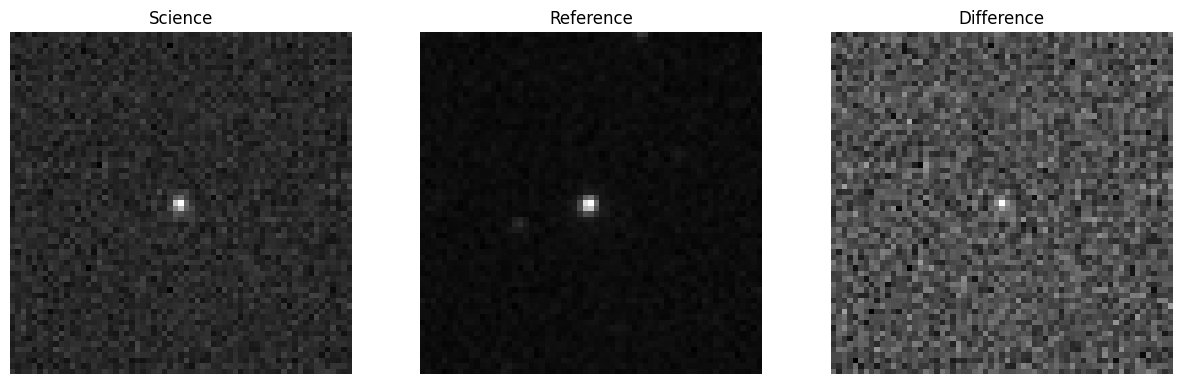

In [ ]:
# Display a sample .fits file to verify it was loaded correctly
visual_fits(f"{DATA_DIR_STAMPS}/ZTF17aabqcyh_stamps.fits")


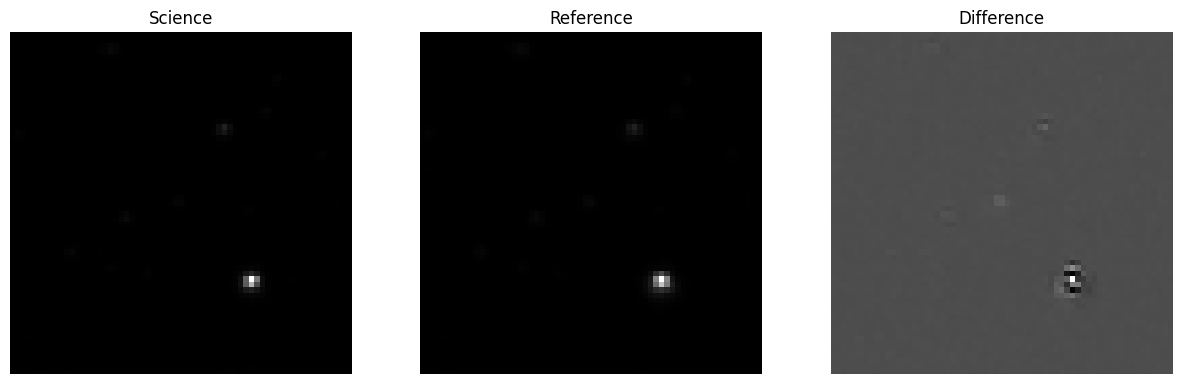

In [ ]:
# Display a sample .fits file to verify it was loaded correctly
visual_fits(f"{DATA_DIR_STAMPS}/ZTF17aaaaana_stamps.fits")

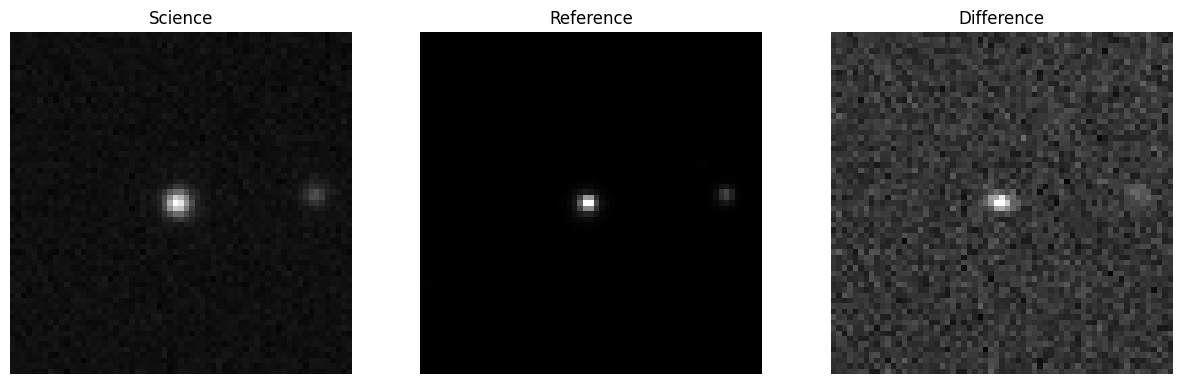

In [29]:
# Display a sample .fits file to verify it was loaded correctly
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

visual_fits(f"{DATA_DIR_STAMPS}/ZTF17aacqtfj_stamps.fits")
plt.savefig(f"{FIGURES_DIR}/stamps.png", dpi=300, bbox_inches="tight")
plt.close()

## Cleaning and Normalization

Once we have identified the `oids` that caused errors during the API download, we remove them from the database. We also verify that all stamp files conform to the expected astronomical format of `(63, 63, 3)`, removing any that do not.


In [12]:
# Clean the labels with errors in the downloading process
labels_clean = clean_labels(labels, to_delete, DATA_DIR_STAMPS)
print(labels.shape, ": original")
print(labels_clean.shape, ": filtered")

(5000, 2) : original
(4911, 2) : filtered


After downloading and cleaning the data, we structure the dataset into the input feature array $\mathbf{X}$ and target vector $\mathbf{y}$ for model training. $\mathbf{X}$ contains the image triplets (Science, Reference, and Difference) for each sample, while $\mathbf{y}$ target the corresponding binary labels (Real or Bogus)

In [13]:
# Define X and y to train
X, y = build_Xy(labels_clean, DATA_DIR_STAMPS)
X = normalize_img(X)

print("X final:", X.shape)
print("y final:", y.shape)

c:\Users\Paul\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\linalg\linalg.py:2621: RuntimeWarning: overflow encountered in multiply
  ret = sqrt(add.reduce((x.conj() * x).real, axis=axis))


X final: (4911, 63, 63, 3)
y final: (4911,)


In [14]:
# Save the current data to continue in notebook II
DATA_DIR_PROCS = "../data/processed"
os.makedirs(DATA_DIR_PROCS, exist_ok=True)
X_save_path = os.path.join(DATA_DIR_PROCS, "X_data.npy")
y_save_path = os.path.join(DATA_DIR_PROCS, "y_labels.npy")

np.save(X_save_path, X)
np.save(y_save_path, y)

## References


- Sánchez-Sáez, P., et al. (2021). *The Automatic Learning for the Rapid Classification of Events (ALeRCE) Alert Broker*. *The Astronomical Journal, 161*(5), 242. https://doi.org/10.3847/1538-3881/abe9bc
- Bellm, E. C., et al. (2019). *The Zwicky Transient Facility: System overview, performance, and first results*. *Publications of the Astronomical Society of the Pacific, 131*(995), 018002. https://doi.org/10.1088/1538-3873/aaecbe
- Masci, F. J., et al. (2019). *The Zwicky Transient Facility: Data Processing, Products, and Archive*. *Publications of the Astronomical Society of the Pacific, 131*(995), 018003. https://doi.org/10.1088/1538-3873/aae8ac